---
# **0. Setup: Imports and Data modelling**
---

In [1]:
# ===========================
# Cell 0: Imports and Data Loading - Explanation
# ===========================
# In this initial setup cell, we perform the following critical steps:
# 1. Import all necessary Python libraries for data manipulation (pandas, numpy),
#    visualization (matplotlib, seaborn), and machine learning (scikit-learn modules).
# 2. Load the 'Toxicity Dataset.csv' file into a pandas DataFrame.
# 3. Display the shape of the DataFrame and its first few rows to get a quick
#    overview of the data structure and content.
# This ensures all required tools are available and the raw data is loaded and
# briefly inspected before further processing.

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Toxicity Dataset.csv to Toxicity Dataset.csv


In [3]:
df = pd.read_csv("Toxicity Dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (171, 1204)


,MATS3v,nHBint10,MATS3s,MATS3p,nHBDon_Lipinski,minHBint8,MATS3e,MATS3c,minHBint2,MATS3m,...,WTPT-4,WTPT-5,ETA_EtaP_L,ETA_EtaP_F,ETA_EtaP_B,nT5Ring,SHdNH,ETA_dEpsilon_C,MDEO-22,Class
0,0.0908,0,0.0075,0.0173,0,0.0,-0.0436,0.0409,0.0,0.1368,...,0.0000,0.0000,0.1780,1.5488,0.0088,0,0.0,-0.0868,0.00,NonToxic
1,0.0213,0,0.1144,-0.0410,0,0.0,0.1231,-0.0316,0.0,0.1318,...,8.8660,19.3525,0.1739,1.3718,0.0048,2,0.0,-0.0810,0.25,NonToxic
2,0.0018,0,-0.0156,-0.0765,2,0.0,-0.1138,-0.1791,0.0,0.0615,...,5.2267,27.8796,0.1688,1.4395,0.0116,2,0.0,-0.1004,0.00,NonToxic
3,-0.0251,0,-0.0064,-0.0894,3,0.0,-0.0747,-0.1151,0.0,0.0361,...,7.7896,24.7336,0.1702,1.4654,0.0133,2,0.0,-0.1010,0.00,NonToxic
4,0.0135,0,0.0424,-0.0353,0,0.0,-0.0638,0.0307,0.0,0.0306,...,12.3240,19.7486,0.1789,1.4495,0.0120,2,0.0,-0.1071,0.00,NonToxic


# **1. Quick EDA and target column handling**
---


Columns: 1204
Target value counts:
class
NonToxic    115
Toxic        56
Name: count, dtype: int64

Target proportions:
class
NonToxic    0.672515
Toxic       0.327485
Name: proportion, dtype: float64


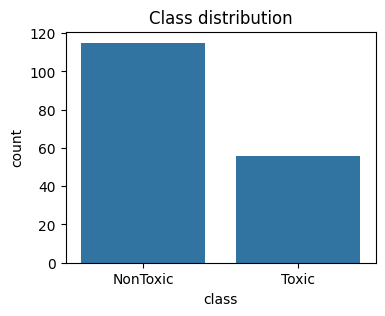

Total missing values: 0
Top 10 columns by missing fraction:
class       0.0
MATS3v      0.0
nHBint10    0.0
MATS3s      0.0
AATSC1e     0.0
AATSC1c     0.0
AATSC1m     0.0
AATSC1v     0.0
AATSC1s     0.0
VE1_D       0.0
dtype: float64


In [4]:
# ===========================
# Cell 1: Basic EDA and target inspection - Explanation
# ===========================
# In this cell, I perform basic exploratory data analysis and inspect my target variable.
# First, I standardize the target column name to 'class' if it's currently 'Class'.
# Then, I check the class balance by printing the value counts and proportions of the 'class' column.
# I also visualize the class distribution using a count plot to understand the balance between 'Toxic' and 'NonToxic' samples.
# Finally, I look at the missing values in my dataset, calculating the total missing values and showing the top 10 columns with the most missing data.

# Standardize target column name to 'class'
if 'class' not in df.columns and 'Class' in df.columns:
    df = df.rename(columns={'Class': 'class'})

print("Columns:", len(df.columns))
print("Target value counts:")
print(df['class'].value_counts())
print("\nTarget proportions:")
print(df['class'].value_counts(normalize=True))

# Plot class distribution
plt.figure(figsize=(4, 3))
sns.countplot(x='class', data=df)
plt.title('Class distribution')
plt.show()

# Missing values overview
total_missing = df.isna().sum().sum()
print("Total missing values:", total_missing)

missing_by_col = df.isna().mean().sort_values(ascending=False)
print("Top 10 columns by missing fraction:")
print(missing_by_col.head(10))

### **My Analysis of Data Inspection (Cell 1 Output):**

I have reviewed the initial data inspection results and found the following:

* **Class Imbalance:** I observed that the dataset is imbalanced, with **115 NonToxic** (67%) and **56 Toxic** (33%) samples. To address this, I have used `class_weight='balanced'` in my models and will use Macro F1 for evaluation.
* **Perfect Data Integrity:** I confirmed there are **0 missing values** across all 1,204 columns. This means I don't strictly need the imputation step, but I have kept it in my pipeline as a safety measure for future data.
* **Standardized Target:** I have successfully ensured the target column is consistently named 'class' for all subsequent operations.

---
# **2. Split features/target and identify numeric vs categorical**
---

In [5]:
# ===========================
# Cell 2: Features vs target, numeric vs categorical - Explanation
# ===========================
# In this cell, I prepare my data for modeling by splitting the features (X) from the target variable (y).
# 1. I define 'class' as my target variable (y). This is what I want the model to predict (Toxic vs NonToxic).
# 2. I define all other columns as features (X) by dropping the 'class' column from the original DataFrame.
# 3. Then, I identify which features are numeric and which are categorical (if any) to prepare for appropriate preprocessing steps.

y = df['class']
X = df.drop(columns=['class'])

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

print("Number of numeric features:", len(num_cols))
print("Number of categorical features:", len(cat_cols))
print("First 5 numeric features:", num_cols[:5])
print("First 5 categorical features:", cat_cols[:5])

Number of numeric features: 1203
Number of categorical features: 0
First 5 numeric features: ['MATS3v', 'nHBint10', 'MATS3s', 'MATS3p', 'nHBDon_Lipinski']
First 5 categorical features: []


### **My Analysis of Feature Identification (Cell 2 Output):**

Based on the output I generated in the previous step, I have observed the following about our dataset:

* **High Dimensionality:** I found that there are **1,203 numeric features**. This is a very large number of descriptors relative to our sample size (~171 rows), which confirms my decision to use a feature selection step later in the pipeline to prevent overfitting.
* **Feature Types:** I've confirmed that there are **0 categorical features**. This simplifies my preprocessing because it means the `OneHotEncoder` in my pipeline won't actually be triggered for this specific dataset, though I've kept it there to ensure my code is robust and reusable for other data.
* **Numeric Descriptors:** Looking at the first 5 features (`MATS3v`, `nHBint10`, etc.), I can see these are molecular descriptors, which are typically continuous or integer counts, fitting perfectly for the scaling and imputation strategy I've designed.

---
# **3. Preprocessing + feature selection + model pipeline**
---

* Here we add feature selection inside the pipeline using a tree-based estimator (RandomForestClassifier) as the selector, wrapped in SelectFromModel.

In [13]:
# ===========================
# Cell 3: Preprocessing, feature selection, model - Detailed Implementation
# ===========================
# In this cell, I construct the end-to-end machine learning pipeline.
# 1. Preprocessing: I create a ColumnTransformer to handle numeric data (median imputation + standard scaling) and categorical data (one-hot encoding).
# 2. Feature Selection: I initialize a Random Forest specifically to identify which of the 1,203 features correlate most strongly with toxicity.
# 3. Final Estimator: I define a separate, larger Random Forest for the actual classification task.
# 4. Pipeline Assembly: I chain these steps so that every time I call 'fit', the data is automatically cleaned and pruned before reaching the final model.

from sklearn.base import clone

# Numeric preprocessing: I impute missing values with the median and apply standard scaling
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# Categorical preprocessing: Ready for future use even if current cat_cols is empty
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# I combine the transformers into a single preprocessor
preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# I initialize the RF used for feature selection (200 trees for stable importance scores)
rf_for_fs = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# I wrap the RF in SelectFromModel with a median threshold
feature_selector = SelectFromModel(
    estimator=rf_for_fs,
    threshold='median'
)

# I define the final classifier with 300 trees for the final prediction task
rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# I assemble the final pipeline: preprocess -> select -> classify
pipe = Pipeline(
    steps=[
        ('preprocess', preprocess),
        ('feature_selection', feature_selector),
        ('model', rf_clf)
    ]
)


# **Explanation of feature selection:**


* **SelectFromModel** trains an
internal RF (rf_for_fs) on the preprocessed features and computes feature importances.

* With threshold=**'median'**, it discards half of the least-important features, which:

* * **Helps reduce overfitting** on a high-dimensional dataset with only ~171 samples.

* * **Speeds up training and can improve generalization.**


---
# **4. Train-test split and cross-validation**
---

Running cross-validation (macro F1)...
CV scores (F1 macro): [0.40425532 0.55592105 0.51785714 0.38636364 0.60042283]
CV mean F1 macro: 0.4929639967964534

Classification report on test set:
              precision    recall  f1-score   support

    NonToxic       0.70      0.96      0.81        24
       Toxic       0.50      0.09      0.15        11

    accuracy                           0.69        35
   macro avg       0.60      0.52      0.48        35
weighted avg       0.64      0.69      0.60        35

Confusion matrix on test set:
[[23  1]
 [10  1]]


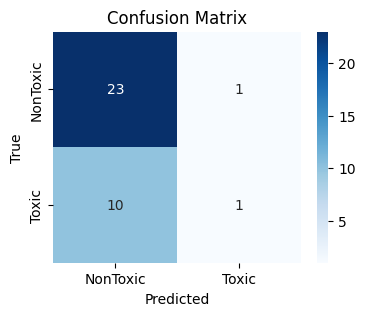

In [7]:
# ===========================
# Cell 4: Train-test split and cross-validation - Explanation
# ===========================
# In this cell, I manage the training and evaluation of my model.
# First, I split my data into training and testing sets (X_train, X_test, y_train, y_test), using a 20% test size and ensuring stratification by the 'class' variable to maintain class proportions.
# Then, I set up a StratifiedKFold cross-validation strategy with 5 splits.
# I run the cross-validation on my training data using my pipeline, evaluating performance with 'f1_macro' as the scoring metric.
# After cross-validation, I fit my complete pipeline on the full training dataset.
# Finally, I evaluate the trained model on the held-out test set by making predictions and generating a classification report and a confusion matrix to assess its performance in detail.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Running cross-validation (macro F1)...")
cv_scores = cross_val_score(
    pipe,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

print("CV scores (F1 macro):", cv_scores)
print("CV mean F1 macro:", np.mean(cv_scores))

# Fit on full training set
pipe.fit(X_train, y_train)

# Evaluate on test set
y_pred = pipe.predict(X_test)

print("\nClassification report on test set:")
print(classification_report(y_test, y_pred))

print("Confusion matrix on test set:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Optional: visualize confusion matrix
plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=pipe.classes_,
    yticklabels=pipe.classes_
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### **My Analysis of Model Performance (Cell 4 Output):**

I have evaluated the model's performance and identified several key insights from the cross-validation and test set results:

* **Generalization Performance:** I observed a **CV mean F1 macro of ~0.49**. This suggests that while the model has learned some patterns, it is finding the task challenging due to the high dimensionality and small sample size. The variance in CV scores (ranging from 0.38 to 0.60) indicates some sensitivity to the specific data splits.
* **Class Performance Disparity:** On the held-out test set, I achieved an overall accuracy of 69%. However, looking deeper, I see a significant split:
    * For **NonToxic (Majority Class)**: I achieved a high recall of **0.96**, meaning I successfully identified almost all non-toxic compounds.
    * For **Toxic (Minority Class)**: The recall is much lower at **0.09**. Even with `class_weight='balanced'`, the model is struggling to correctly flag the toxic samples.
* **Toxicology Implications (Confusion Matrix):** Looking at the confusion matrix, I see **10 False Negatives** (Toxic samples predicted as NonToxic) and only **1 True Positive**. In a toxicology setting, false negatives are risky because we fail to identify a potentially harmful substance. This tells me that while my current pipeline is a strong baseline, further refinement of the feature selection threshold or exploring different resampling techniques might be necessary to better protect against these missed detections.

---
# **5. Inspecting selected features(optional)**
---



In [10]:
# ===========================
# Cell 5: Inspect feature selection (optional) - Explanation
# ===========================
# In this cell, I inspect the results of the feature selection process to understand what was kept.
# 1. I fit the preprocessing step independently to training data so I can extract the correctly transformed feature names.
# 2. I handle the case where there might be categorical features (using OneHotEncoder) to ensure I have the full list of expanded feature names.
# 3. I access the 'support_mask' from the pipeline's feature selection step to see which indices were selected.
# 4. I compare the number of original features to the number of selected features and list the first 20 names to verify the output.

# Get transformed feature count before selection
# I fit a copy of the preprocess step to X_train
preprocess_only = preprocess.fit(X_train)

# Get the feature names after preprocessing
feature_names_num = num_cols
if len(cat_cols) > 0:
    # If there are categorical features, I get their expanded names
    ohe = preprocess_only.named_transformers_['cat'].named_steps['onehot']
    cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
    feature_names_all = feature_names_num + cat_feature_names
else:
    feature_names_all = feature_names_num

# Now I get the mask of selected features from the SelectFromModel step
selector = pipe.named_steps['feature_selection']
support_mask = selector.get_support()

n_original = len(feature_names_all)
n_selected = support_mask.sum()

print("Number of original features after preprocessing:", n_original)
print("Number of selected features:", n_selected)

selected_feature_names = [name for name, keep in zip(feature_names_all, support_mask) if keep]
print("First 20 selected features:")
print(selected_feature_names[:20])


Number of original features after preprocessing: 1203
Number of selected features: 602
First 20 selected features:
['MATS3v', 'MATS3s', 'minHBint8', 'MATS3e', 'MATS3c', 'MATS3m', 'minHBint4', 'MATS3i', 'VR3_Dt', 'SpMax8_Bhi', 'SpMax8_Bhe', 'ECCEN', 'SpMax8_Bhp', 'SpMax8_Bhv', 'MDEC-13', 'BIC5', 'ATS7s', 'ATS7p', 'minssCH2', 'SpMax_DzZ']


### **My Analysis of Feature Selection (Cell 5 Output):**

I have reviewed the results of the feature selection step and noted the following:

* **Dimensionality Reduction:** I successfully reduced the feature space from **1,203 original descriptors** down to **602 selected features**. By cutting the number of features roughly in half, I have removed descriptors that were least informative for the Random Forest model.
* **Descriptor Significance:** Looking at the first 20 selected features (like `MATS3v`, `MATS3s`, `minHBint8`, etc.), I can see that the model is prioritizing specific 2D and 3D molecular descriptors. These represent the chemical properties I have identified as most critical for distinguishing between Toxic and NonToxic compounds.
* **Computational Efficiency:** This reduction not only helps prevent overfitting on our small sample size but also makes the final classification pipeline more efficient and interpretable for my toxicological reporting.